# ASCON-AEAD128 Byte 00 Traditional DPA/CPA Ranking

This notebook analyzes your **fixed-key + random-nonce ASCON byte 00 dataset**.

It runs two classical baselines:

1. **Simple byte CPA baseline** using `HW(nonce_byte0 XOR key_guess)`.
2. **Paper-style Ascon first-round x0 selection-function CPA/DPA** based on the Samwel & Daemen Ascon DPA paper.

Important: if the firmware trace window still captures direct key-byte loading instead of Ascon first-round key/nonce mixing, the paper-style DPA/CPA may not recover the key even with 30,000 traces. That result is still useful: it tells you the current capture window is not suitable for classical DPA/CPA.

In [1]:
# Cell 1 - Imports and paths

from pathlib import Path
import os, json, math, time, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path(r"C:\Users\thetp\Downloads\ASCON_FYP")
DATA_ROOT = PROJECT_ROOT / "03_Data" / "fixedkey_randomnonce_dpa_validation"
RESULTS_ROOT = PROJECT_ROOT / "04_Results" / "ascon_dpa_cpa_byte00"
RESULTS_ROOT.mkdir(parents=True, exist_ok=True)

# Exact byte00 fixed-key random-nonce DPA validation run folder provided by user.
# Set DATASET_RUN = None if you want auto-detection instead.
DATASET_RUN = Path(r"C:\Users\thetp\Downloads\ASCON_FYP\03_Data\fixedkey_randomnonce_dpa_validation\ascon_fixedkey_randomnonce_dpa_20260603_235756")

TARGET_BYTE = 0
TRACE_KEY_CANDIDATES = ["traces", "arr_0", "waveforms", "X"]

TOPK_VALUES = [1, 2, 4, 8, 16, 32]

# For quick testing, set MAX_TRACES = 5000.
# For final byte00 result, use MAX_TRACES = None to use all 30,000 traces.
MAX_TRACES = None

# CPA/DPA options
APPLY_TRACE_NORMALIZATION = True
CROP_START = 0
CROP_END = 2000

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_ROOT:", DATA_ROOT)
print("RESULTS_ROOT:", RESULTS_ROOT)

PROJECT_ROOT: C:\Users\thetp\Downloads\ASCON_FYP
DATA_ROOT: C:\Users\thetp\Downloads\ASCON_FYP\03_Data\fixedkey_randomnonce_dpa_validation
RESULTS_ROOT: C:\Users\thetp\Downloads\ASCON_FYP\04_Results\ascon_dpa_cpa_byte00


In [2]:
# Cell 2 - Auto-detect the real dataset run folder

def count_files_for_byte(run_dir: Path, target_byte: int):
    byte_dir = run_dir / f"byte_{target_byte:02d}"
    trace_files = sorted(byte_dir.glob(f"byte{target_byte:02d}_chunk_*_traces.npz"))
    meta_files = sorted(byte_dir.glob(f"byte{target_byte:02d}_chunk_*_metadata.csv"))
    return byte_dir, trace_files, meta_files

if DATASET_RUN is None:
    candidates = []
    for p in sorted(DATA_ROOT.glob("ascon_fixedkey_randomnonce_dpa_*")):
        if not p.is_dir():
            continue
        byte_dir, trace_files, meta_files = count_files_for_byte(p, TARGET_BYTE)
        candidates.append({
            "run_dir": p,
            "byte_dir": byte_dir,
            "trace_files": len(trace_files),
            "metadata_files": len(meta_files),
            "modified_time": p.stat().st_mtime,
        })
    cand_df = pd.DataFrame(candidates)
    display(cand_df.sort_values("modified_time", ascending=False))
    valid = [c for c in candidates if c["trace_files"] > 0 and c["metadata_files"] > 0]
    if not valid:
        raise FileNotFoundError(f"No valid fixed-key random-nonce ASCON run found under {DATA_ROOT}")
    # Prefer folders with most chunks, then latest modified time.
    valid = sorted(valid, key=lambda x: (x["trace_files"], x["metadata_files"], x["modified_time"]), reverse=True)
    DATASET_RUN = valid[0]["run_dir"]

BYTE_DIR, TRACE_FILES, META_FILES = count_files_for_byte(DATASET_RUN, TARGET_BYTE)

print("Selected DATASET_RUN:", DATASET_RUN)
print("BYTE_DIR:", BYTE_DIR)
print("Trace files:", len(TRACE_FILES))
print("Metadata files:", len(META_FILES))

if len(TRACE_FILES) == 0 or len(META_FILES) == 0:
    raise FileNotFoundError("No trace/metadata chunks found for byte 00.")

Selected DATASET_RUN: C:\Users\thetp\Downloads\ASCON_FYP\03_Data\fixedkey_randomnonce_dpa_validation\ascon_fixedkey_randomnonce_dpa_20260603_235756
BYTE_DIR: C:\Users\thetp\Downloads\ASCON_FYP\03_Data\fixedkey_randomnonce_dpa_validation\ascon_fixedkey_randomnonce_dpa_20260603_235756\byte_00
Trace files: 30
Metadata files: 30


In [3]:
# Cell 3 - Load byte 00 traces and metadata

def load_npz_traces(npz_path: Path):
    z = np.load(npz_path)
    for key in TRACE_KEY_CANDIDATES:
        if key in z.files:
            return z[key].astype(np.float32)
    if len(z.files) == 1:
        return z[z.files[0]].astype(np.float32)
    raise KeyError(f"Cannot identify trace array inside {npz_path}. Keys: {z.files}")

all_X = []
all_meta = []
chunk_report = []
loaded = 0

for tf, mf in zip(TRACE_FILES, META_FILES):
    Xc = load_npz_traces(tf)
    mc = pd.read_csv(mf)
    chunk_report.append({
        "trace_file": tf.name,
        "metadata_file": mf.name,
        "trace_rows": len(Xc),
        "metadata_rows": len(mc),
        "matched": len(Xc) == len(mc),
    })
    if len(Xc) != len(mc):
        print("WARNING: skipping mismatched chunk", tf.name, mf.name, Xc.shape, mc.shape)
        continue
    all_X.append(Xc)
    all_meta.append(mc)
    loaded += len(Xc)
    if MAX_TRACES is not None and loaded >= MAX_TRACES:
        break

chunk_df = pd.DataFrame(chunk_report)
display(chunk_df)

X = np.vstack(all_X)
meta = pd.concat(all_meta, ignore_index=True)

if MAX_TRACES is not None and len(X) > MAX_TRACES:
    X = X[:MAX_TRACES]
    meta = meta.iloc[:MAX_TRACES].reset_index(drop=True)

X = X[:, CROP_START:CROP_END].astype(np.float32)

print("X shape:", X.shape)
print("Metadata shape:", meta.shape)
print("Columns:", list(meta.columns))

,trace_file,metadata_file,trace_rows,metadata_rows,matched
0,byte00_chunk_0000_traces.npz,byte00_chunk_0000_metadata.csv,1000,1000,True
1,byte00_chunk_0001_traces.npz,byte00_chunk_0001_metadata.csv,1000,1000,True
2,byte00_chunk_0002_traces.npz,byte00_chunk_0002_metadata.csv,1000,1000,True
3,byte00_chunk_0003_traces.npz,byte00_chunk_0003_metadata.csv,1000,1000,True
4,byte00_chunk_0004_traces.npz,byte00_chunk_0004_metadata.csv,1000,1000,True
5,byte00_chunk_0005_traces.npz,byte00_chunk_0005_metadata.csv,1000,1000,True
6,byte00_chunk_0006_traces.npz,byte00_chunk_0006_metadata.csv,1000,1000,True
7,byte00_chunk_0007_traces.npz,byte00_chunk_0007_metadata.csv,1000,1000,True
8,byte00_chunk_0008_traces.npz,byte00_chunk_0008_metadata.csv,1000,1000,True
9,byte00_chunk_0009_traces.npz,byte00_chunk_0009_metadata.csv,1000,1000,True


X shape: (30000, 2000)
Metadata shape: (30000, 23)
Columns: ['algorithm', 'dataset_type', 'fixed_key_id', 'target_byte', 'trace_index', 'attempt_index', 'key_hex', 'nonce_hex', 'key_byte_value', 'key_byte_hex', 'key_byte_hw', 'output_hex', 'trigger_count', 'capture_ret', 'raw_text', 'bit0_lsb', 'bit1_lsb', 'bit2_lsb', 'bit3_lsb', 'bit4_lsb', 'bit5_lsb', 'bit6_lsb', 'bit7_lsb']


In [4]:
# Cell 4 - Metadata checks

required_cols = ["key_hex", "nonce_hex", "target_byte", "key_byte_value", "key_byte_hex", "trigger_count", "capture_ret"]
missing = [c for c in required_cols if c not in meta.columns]
if missing:
    raise ValueError(f"Missing required metadata columns: {missing}")

meta["key_hex"] = meta["key_hex"].astype(str).str.lower().str.zfill(32)
meta["nonce_hex"] = meta["nonce_hex"].astype(str).str.lower().str.zfill(32)

unique_keys = meta["key_hex"].nunique()
unique_nonces = meta["nonce_hex"].nunique()
fixed_key_hex = meta["key_hex"].iloc[0]
true_key_byte = int(fixed_key_hex[TARGET_BYTE*2:TARGET_BYTE*2+2], 16)

checks = {
    "rows": len(meta),
    "unique_keys": int(unique_keys),
    "fixed_key_hex": fixed_key_hex,
    "target_byte": int(TARGET_BYTE),
    "true_key_byte_hex": f"{true_key_byte:02x}",
    "true_key_byte_dec": int(true_key_byte),
    "unique_nonces": int(unique_nonces),
    "trace_len_after_crop": int(X.shape[1]),
    "trigger_count_min": int(pd.to_numeric(meta["trigger_count"]).min()),
    "trigger_count_max": int(pd.to_numeric(meta["trigger_count"]).max()),
    "capture_ret_values": sorted(meta["capture_ret"].astype(str).unique().tolist()),
}

print(json.dumps(checks, indent=2))

with open(RESULTS_ROOT / "byte00_metadata_checks.json", "w", encoding="utf-8") as f:
    json.dump(checks, f, indent=2)

{
  "rows": 30000,
  "unique_keys": 1,
  "fixed_key_hex": "00112233445566778899aabbccddeeff",
  "target_byte": 0,
  "true_key_byte_hex": "00",
  "true_key_byte_dec": 0,
  "unique_nonces": 30000,
  "trace_len_after_crop": 2000,
  "trigger_count_min": 332,
  "trigger_count_max": 332,
  "capture_ret_values": [
    "False"
  ]
}


In [5]:
# Cell 5 - Trace preprocessing

# Convert nonce hex to bytes array: shape (N, 16)
nonce_bytes = np.array([list(bytes.fromhex(h)) for h in meta["nonce_hex"].values], dtype=np.uint8)
key_bytes = bytes.fromhex(fixed_key_hex)

X_work = X.astype(np.float32)

# Remove per-sample mean across traces for CPA stability.
X_work = X_work - X_work.mean(axis=0, keepdims=True)

if APPLY_TRACE_NORMALIZATION:
    # Normalize each trace to reduce amplitude drift.
    mu = X_work.mean(axis=1, keepdims=True)
    sd = X_work.std(axis=1, keepdims=True) + 1e-8
    X_work = (X_work - mu) / sd

print("Prepared X_work:", X_work.shape, X_work.dtype)
print("Mean/std overall:", float(X_work.mean()), float(X_work.std()))

Prepared X_work: (30000, 2000) float32
Mean/std overall: 6.540298302937231e-10 0.9999974370002747


In [6]:
# Cell 6 - Helper functions for CPA/DPA

HW_TABLE = np.array([bin(i).count("1") for i in range(256)], dtype=np.float32)

def pearson_corr_scores(Xmat, hyp):
    """Return correlation between hyp vector and every time sample."""
    h = hyp.astype(np.float32)
    h = h - h.mean()
    denom_h = np.sqrt(np.sum(h * h)) + 1e-12
    # Xmat is already centered approximately, but center again per sample for safety.
    Xm = Xmat - Xmat.mean(axis=0, keepdims=True)
    denom_x = np.sqrt(np.sum(Xm * Xm, axis=0)) + 1e-12
    corr = (h @ Xm) / (denom_h * denom_x)
    return corr

def dpa_diff_scores(Xmat, bit_hyp):
    bit_hyp = bit_hyp.astype(np.uint8)
    if bit_hyp.sum() == 0 or bit_hyp.sum() == len(bit_hyp):
        return np.zeros(Xmat.shape[1], dtype=np.float32)
    mean0 = Xmat[bit_hyp == 0].mean(axis=0)
    mean1 = Xmat[bit_hyp == 1].mean(axis=0)
    return mean1 - mean0

def rank_from_scores(scores, true_candidate):
    order = np.argsort(-scores)  # descending
    rank = int(np.where(order == int(true_candidate))[0][0]) + 1
    topk = {}
    for k in TOPK_VALUES:
        topk[f"top{k}"] = bool(int(true_candidate) in order[:k])
    return order, rank, topk

def get_bit_from_bytes(byte_array, bit_index):
    """LSB bit ordering across 64-bit word: byte index = bit//8, bit within byte = bit%8."""
    byte_idx = bit_index // 8
    bit_idx = bit_index % 8
    return ((byte_array[:, byte_idx] >> bit_idx) & 1).astype(np.uint8)

def get_key_bit_lsb(key_bytes_obj, bit_index):
    byte_idx = bit_index // 8
    bit_idx = bit_index % 8
    return (key_bytes_obj[byte_idx] >> bit_idx) & 1

In [7]:
# Cell 7 - Baseline 1: Simple byte CPA using HW(nonce_byte0 XOR key_guess)
# This is NOT the exact Ascon paper selection function.
# It is a simple classical CPA sanity baseline for byte-level ranking.

nonce_byte_index = TARGET_BYTE  # byte 0
true_candidate = true_key_byte

simple_cpa_scores = np.zeros(256, dtype=np.float32)
simple_cpa_peak_points = np.zeros(256, dtype=np.int32)

start = time.time()
for guess in range(256):
    hyp = HW_TABLE[np.bitwise_xor(nonce_bytes[:, nonce_byte_index], guess)]
    corr = pearson_corr_scores(X_work, hyp)
    abs_corr = np.abs(corr)
    simple_cpa_scores[guess] = float(abs_corr.max())
    simple_cpa_peak_points[guess] = int(abs_corr.argmax()) + CROP_START

simple_order, simple_rank, simple_topk = rank_from_scores(simple_cpa_scores, true_candidate)

simple_result = {
    "method": "simple_byte_cpa_hw_nonce_xor_guess",
    "true_key_byte_hex": f"{true_candidate:02x}",
    "true_key_byte_dec": int(true_candidate),
    "true_rank": int(simple_rank),
    "best_guess_hex": f"{int(simple_order[0]):02x}",
    "best_guess_score": float(simple_cpa_scores[int(simple_order[0])]),
    "true_guess_score": float(simple_cpa_scores[int(true_candidate)]),
    "elapsed_seconds": float(time.time() - start),
}
simple_result.update({k: int(v) for k, v in simple_topk.items()})

print(json.dumps(simple_result, indent=2))
print("Top 10 guesses:", [f"{g:02x}" for g in simple_order[:10]])

pd.DataFrame([simple_result]).to_csv(RESULTS_ROOT / "byte00_simple_byte_cpa_summary.csv", index=False)
pd.DataFrame({
    "candidate": np.arange(256),
    "candidate_hex": [f"{i:02x}" for i in range(256)],
    "score": simple_cpa_scores,
    "peak_point": simple_cpa_peak_points,
}).sort_values("score", ascending=False).to_csv(RESULTS_ROOT / "byte00_simple_byte_cpa_candidate_scores.csv", index=False)

{
  "method": "simple_byte_cpa_hw_nonce_xor_guess",
  "true_key_byte_hex": "00",
  "true_key_byte_dec": 0,
  "true_rank": 218,
  "best_guess_hex": "53",
  "best_guess_score": 0.026090547442436218,
  "true_guess_score": 0.014704504981637001,
  "elapsed_seconds": 28.580092191696167,
  "top1": 0,
  "top2": 0,
  "top4": 0,
  "top8": 0,
  "top16": 0,
  "top32": 0
}
Top 10 guesses: ['53', 'ac', '2c', 'd3', '5b', 'a4', 'd7', '28', '6c', '93']


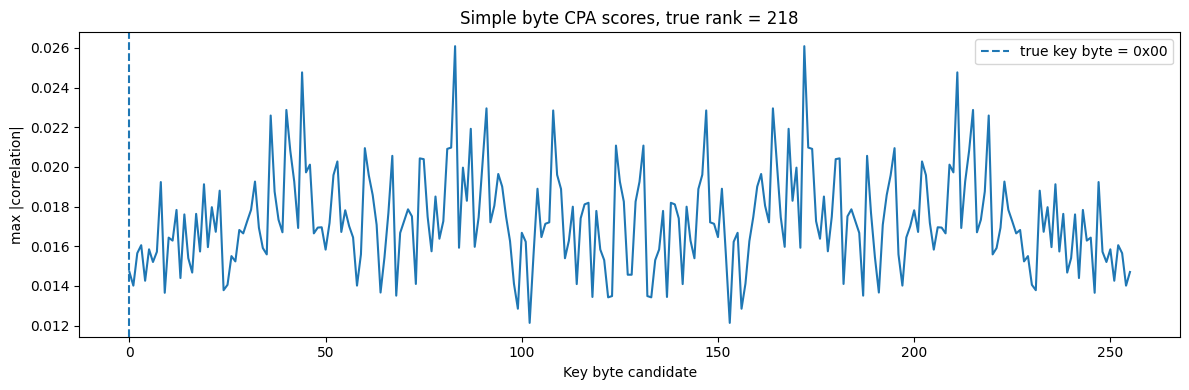

In [8]:
# Cell 8 - Plot simple CPA candidate ranking

plt.figure(figsize=(12, 4))
plt.plot(simple_cpa_scores)
plt.axvline(true_candidate, linestyle="--", label=f"true key byte = 0x{true_candidate:02x}")
plt.title(f"Simple byte CPA scores, true rank = {simple_rank}")
plt.xlabel("Key byte candidate")
plt.ylabel("max |correlation|")
plt.legend()
plt.tight_layout()
plt.savefig(RESULTS_ROOT / "byte00_simple_byte_cpa_scores.png", dpi=160)
plt.show()

## Paper-style Ascon x0 selection function

The Samwel & Daemen Ascon DPA paper attacks the end of the first Ascon round. For register `x0'`, the selection function for bit position `i` is:

```text
S_i(M,K*) = k0*(m'_i + 1) + m_i
          + k1*(m'_{i+45} + 1) + m_{i+45}
          + k2*(m'_{i+36} + 1) + m_{i+36}
```

All operations are in GF(2), so `+` means XOR and multiplication means AND.

Here:

- `m` is nonce register `x3`, nonce bits 0..63.
- `m'` is nonce register `x4`, nonce bits 64..127.
- `k0`, `k1`, `k2` are three guessed key bits.
- There are `2^3 = 8` candidates per attacked bit expression.

This cell ranks those 8 candidates using both CPA and DPA.

In [9]:
# Cell 9 - Paper-style Ascon x0 triplet CPA/DPA for i = 0..7
# This tests whether the current trace window behaves like the paper's first-round leakage.

def selection_x0_triplet(nonce_bytes_arr, i, cand3):
    # Candidate bits.
    k0 = (cand3 >> 0) & 1
    k1 = (cand3 >> 1) & 1
    k2 = (cand3 >> 2) & 1

    # m = x3 = first 64 nonce bits, m' = x4 = second 64 nonce bits.
    idx0 = i % 64
    idx1 = (i + 45) % 64
    idx2 = (i + 36) % 64

    m0 = get_bit_from_bytes(nonce_bytes_arr[:, 0:8], idx0)
    m1 = get_bit_from_bytes(nonce_bytes_arr[:, 0:8], idx1)
    m2 = get_bit_from_bytes(nonce_bytes_arr[:, 0:8], idx2)

    mp0 = get_bit_from_bytes(nonce_bytes_arr[:, 8:16], idx0)
    mp1 = get_bit_from_bytes(nonce_bytes_arr[:, 8:16], idx1)
    mp2 = get_bit_from_bytes(nonce_bytes_arr[:, 8:16], idx2)

    # GF(2): addition is XOR; multiplication is AND.
    S = ((k0 & (mp0 ^ 1)) ^ m0 ^
         (k1 & (mp1 ^ 1)) ^ m1 ^
         (k2 & (mp2 ^ 1)) ^ m2)
    return S.astype(np.uint8)

triplet_rows = []
triplet_cpa_scores_by_i = {}
triplet_dpa_scores_by_i = {}

start = time.time()
for i in range(8):
    true_k0 = get_key_bit_lsb(key_bytes, i)
    true_k1 = get_key_bit_lsb(key_bytes, (i + 45) % 64)
    true_k2 = get_key_bit_lsb(key_bytes, (i + 36) % 64)
    true_triplet = true_k0 | (true_k1 << 1) | (true_k2 << 2)

    cpa_scores = np.zeros(8, dtype=np.float32)
    dpa_scores = np.zeros(8, dtype=np.float32)
    cpa_peak_points = np.zeros(8, dtype=np.int32)
    dpa_peak_points = np.zeros(8, dtype=np.int32)

    for cand in range(8):
        hyp = selection_x0_triplet(nonce_bytes, i, cand)

        corr = pearson_corr_scores(X_work, hyp.astype(np.float32))
        abs_corr = np.abs(corr)
        cpa_scores[cand] = float(abs_corr.max())
        cpa_peak_points[cand] = int(abs_corr.argmax()) + CROP_START

        dpa_curve = dpa_diff_scores(X_work, hyp)
        abs_dpa = np.abs(dpa_curve)
        dpa_scores[cand] = float(abs_dpa.max())
        dpa_peak_points[cand] = int(abs_dpa.argmax()) + CROP_START

    cpa_order, cpa_rank, cpa_topk = rank_from_scores(cpa_scores, true_triplet)
    dpa_order, dpa_rank, dpa_topk = rank_from_scores(dpa_scores, true_triplet)

    triplet_cpa_scores_by_i[i] = cpa_scores
    triplet_dpa_scores_by_i[i] = dpa_scores

    triplet_rows.append({
        "i": i,
        "true_k0_bit_i": int(true_k0),
        "true_k1_bit_i_plus_45": int(true_k1),
        "true_k2_bit_i_plus_36": int(true_k2),
        "true_triplet": int(true_triplet),
        "true_triplet_bits": f"{true_k2}{true_k1}{true_k0}",
        "cpa_rank": int(cpa_rank),
        "cpa_best_candidate": int(cpa_order[0]),
        "cpa_best_score": float(cpa_scores[int(cpa_order[0])]),
        "cpa_true_score": float(cpa_scores[int(true_triplet)]),
        "cpa_peak_point_best": int(cpa_peak_points[int(cpa_order[0])]),
        "dpa_rank": int(dpa_rank),
        "dpa_best_candidate": int(dpa_order[0]),
        "dpa_best_score": float(dpa_scores[int(dpa_order[0])]),
        "dpa_true_score": float(dpa_scores[int(true_triplet)]),
        "dpa_peak_point_best": int(dpa_peak_points[int(dpa_order[0])]),
    })

triplet_df = pd.DataFrame(triplet_rows)
triplet_df.to_csv(RESULTS_ROOT / "byte00_paper_x0_triplet_cpa_dpa_summary.csv", index=False)

print("Elapsed:", time.time() - start)
display(triplet_df)

Elapsed: 10.383779048919678


,i,true_k0_bit_i,true_k1_bit_i_plus_45,true_k2_bit_i_plus_36,true_triplet,true_triplet_bits,cpa_rank,cpa_best_candidate,cpa_best_score,cpa_true_score,cpa_peak_point_best,dpa_rank,dpa_best_candidate,dpa_best_score,dpa_true_score,dpa_peak_point_best
0,0,0,0,0,0,000,3,4,0.022778,0.021292,1540,3,4,0.055002,0.048487,577
1,1,0,1,0,2,010,4,0,0.022776,0.016681,270,4,0,0.045188,0.036860,270
2,2,0,0,1,4,100,3,7,0.024498,0.019240,454,8,7,0.055423,0.034049,454
3,3,0,0,0,0,000,3,4,0.021242,0.019647,1117,3,4,0.046618,0.042757,137
4,4,0,1,1,6,110,5,3,0.021826,0.016169,700,8,1,0.051698,0.029360,1605
5,5,0,1,0,2,010,3,0,0.022332,0.018906,610,3,0,0.046145,0.039340,610
6,6,0,0,1,4,100,8,7,0.024555,0.016927,1162,8,7,0.052846,0.031375,1162
7,7,0,0,0,0,000,2,7,0.019864,0.017322,1542,5,3,0.043470,0.035414,1193


In [10]:
# Cell 10 - Convert paper-style x0 triplet scores into a marginal byte00 ranking
# For each byte candidate, each bit i must match candidate bit i.
# The other two key bits in the triplet are treated as nuisance variables and maximized over.

byte_cpa_scores = np.zeros(256, dtype=np.float32)
byte_dpa_scores = np.zeros(256, dtype=np.float32)

for cand_byte in range(256):
    total_cpa = 0.0
    total_dpa = 0.0
    for i in range(8):
        bit_i = (cand_byte >> i) & 1
        # Candidate triplets where k0 == bit_i. k1/k2 are unknown nuisance bits.
        possible_triplets = [t for t in range(8) if (t & 1) == bit_i]
        total_cpa += float(np.max(triplet_cpa_scores_by_i[i][possible_triplets]))
        total_dpa += float(np.max(triplet_dpa_scores_by_i[i][possible_triplets]))
    byte_cpa_scores[cand_byte] = total_cpa
    byte_dpa_scores[cand_byte] = total_dpa

paper_cpa_order, paper_cpa_rank, paper_cpa_topk = rank_from_scores(byte_cpa_scores, true_key_byte)
paper_dpa_order, paper_dpa_rank, paper_dpa_topk = rank_from_scores(byte_dpa_scores, true_key_byte)

paper_byte_rows = [
    {
        "method": "paper_x0_marginal_byte00_cpa",
        "true_key_byte_hex": f"{true_key_byte:02x}",
        "true_rank": int(paper_cpa_rank),
        "best_guess_hex": f"{int(paper_cpa_order[0]):02x}",
        "true_score": float(byte_cpa_scores[true_key_byte]),
        "best_score": float(byte_cpa_scores[int(paper_cpa_order[0])]),
        **{k: int(v) for k, v in paper_cpa_topk.items()},
    },
    {
        "method": "paper_x0_marginal_byte00_dpa",
        "true_key_byte_hex": f"{true_key_byte:02x}",
        "true_rank": int(paper_dpa_rank),
        "best_guess_hex": f"{int(paper_dpa_order[0]):02x}",
        "true_score": float(byte_dpa_scores[true_key_byte]),
        "best_score": float(byte_dpa_scores[int(paper_dpa_order[0])]),
        **{k: int(v) for k, v in paper_dpa_topk.items()},
    },
]

paper_byte_df = pd.DataFrame(paper_byte_rows)
paper_byte_df.to_csv(RESULTS_ROOT / "byte00_paper_x0_marginal_byte_ranking_summary.csv", index=False)

display(paper_byte_df)

pd.DataFrame({
    "candidate": np.arange(256),
    "candidate_hex": [f"{i:02x}" for i in range(256)],
    "paper_x0_cpa_score": byte_cpa_scores,
    "paper_x0_dpa_score": byte_dpa_scores,
}).sort_values("paper_x0_cpa_score", ascending=False).to_csv(RESULTS_ROOT / "byte00_paper_x0_marginal_byte_candidate_scores.csv", index=False)

print("Paper x0 CPA Top 10:", [f"{g:02x}" for g in paper_cpa_order[:10]])
print("Paper x0 DPA Top 10:", [f"{g:02x}" for g in paper_dpa_order[:10]])

,method,true_key_byte_hex,true_rank,best_guess_hex,true_score,best_score,top1,top2,top4,top8,top16,top32
0,paper_x0_marginal_byte00_cpa,00,183,d4,0.166666,0.179872,0,0,0,0,0,0
1,paper_x0_marginal_byte00_dpa,00,217,d4,0.367393,0.396391,0,0,0,0,0,0


Paper x0 CPA Top 10: ['d4', '94', 'd5', '95', 'dc', '9c', 'dd', '9d', '54', 'd6']
Paper x0 DPA Top 10: ['d4', 'dc', 'f4', 'd6', '94', 'fc', 'de', 'f6', '9c', 'b4']


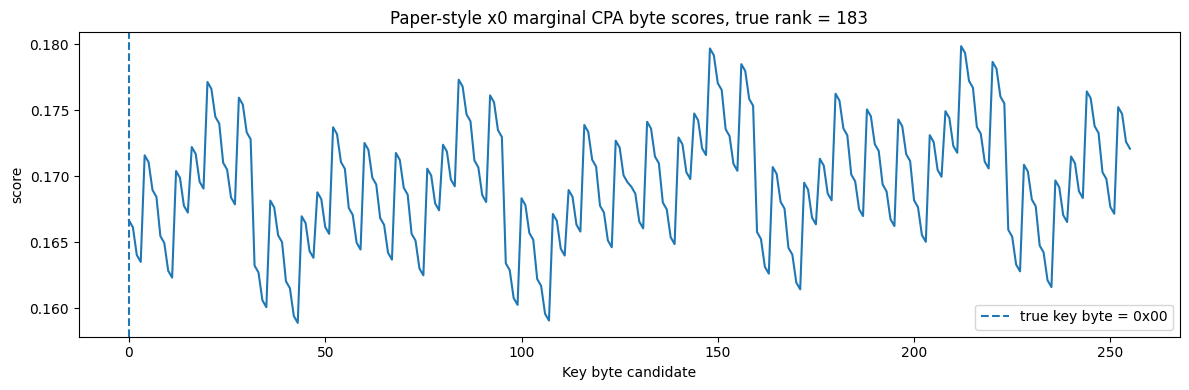

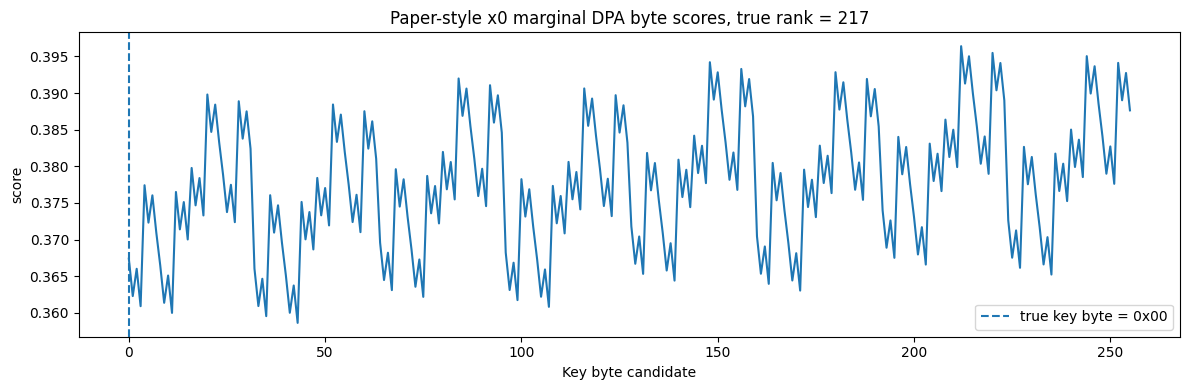

In [11]:
# Cell 11 - Plot paper-style marginal byte scores

plt.figure(figsize=(12, 4))
plt.plot(byte_cpa_scores)
plt.axvline(true_key_byte, linestyle="--", label=f"true key byte = 0x{true_key_byte:02x}")
plt.title(f"Paper-style x0 marginal CPA byte scores, true rank = {paper_cpa_rank}")
plt.xlabel("Key byte candidate")
plt.ylabel("score")
plt.legend()
plt.tight_layout()
plt.savefig(RESULTS_ROOT / "byte00_paper_x0_marginal_cpa_scores.png", dpi=160)
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(byte_dpa_scores)
plt.axvline(true_key_byte, linestyle="--", label=f"true key byte = 0x{true_key_byte:02x}")
plt.title(f"Paper-style x0 marginal DPA byte scores, true rank = {paper_dpa_rank}")
plt.xlabel("Key byte candidate")
plt.ylabel("score")
plt.legend()
plt.tight_layout()
plt.savefig(RESULTS_ROOT / "byte00_paper_x0_marginal_dpa_scores.png", dpi=160)
plt.show()

In [12]:
# Cell 12 - Final interpretation helper

final_summary = pd.concat([
    pd.read_csv(RESULTS_ROOT / "byte00_simple_byte_cpa_summary.csv"),
    pd.read_csv(RESULTS_ROOT / "byte00_paper_x0_marginal_byte_ranking_summary.csv"),
], ignore_index=True)

final_summary.to_csv(RESULTS_ROOT / "byte00_dpa_cpa_final_summary.csv", index=False)
display(final_summary)

print("Saved all results to:", RESULTS_ROOT)
print()
print("Interpretation guide:")
print("- If true_rank is close to 1, DPA/CPA is recovering the key byte well.")
print("- If true_rank is far from 1, this capture window or leakage model is not suitable for classical DPA/CPA.")
print("- If paper-style x0 is weak, your current firmware probably does not capture the same first-round operation attacked in the paper.")

,method,true_key_byte_hex,true_key_byte_dec,true_rank,best_guess_hex,best_guess_score,true_guess_score,elapsed_seconds,top1,top2,top4,top8,top16,top32,true_score,best_score
0,simple_byte_cpa_hw_nonce_xor_guess,0,0.0,218,53,0.026091,0.014705,28.580092,0,0,0,0,0,0,NaN,NaN
1,paper_x0_marginal_byte00_cpa,0,NaN,183,d4,NaN,NaN,NaN,0,0,0,0,0,0,0.166666,0.179872
2,paper_x0_marginal_byte00_dpa,0,NaN,217,d4,NaN,NaN,NaN,0,0,0,0,0,0,0.367393,0.396391


Saved all results to: C:\Users\thetp\Downloads\ASCON_FYP\04_Results\ascon_dpa_cpa_byte00

Interpretation guide:
- If true_rank is close to 1, DPA/CPA is recovering the key byte well.
- If true_rank is far from 1, this capture window or leakage model is not suitable for classical DPA/CPA.
- If paper-style x0 is weak, your current firmware probably does not capture the same first-round operation attacked in the paper.
